# Training a multi-class classifier (Mini-batch GD, B) - PyTorch Version for MNIST

We train with mini-batch gradient descent (batch size B) using PyTorch with hooks to capture gradients and intermediate computations for multi-class classification.

Using device: cuda
Dataset: 900 samples, 784 features, 3 classes
Class distribution: tensor([300, 300, 300], device='cuda:0')
Data shape: X=torch.Size([900, 784]), y=torch.Size([900])
Feature dimension (flattened images): 784


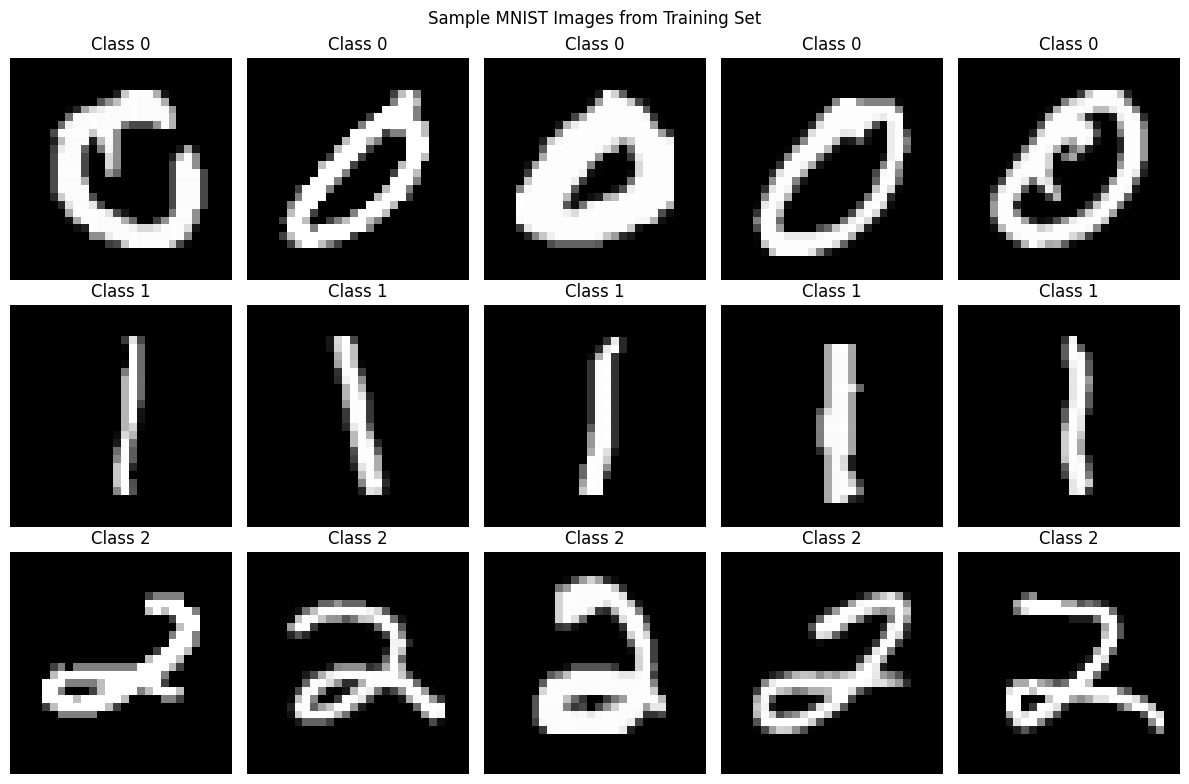

Initial parameters:
Weight shape: torch.Size([3, 784])
Bias shape: torch.Size([3])
Epoch 0: Loss = 0.1440, Acc = 0.9644
Epoch 100: Loss = 0.0095, Acc = 1.0000
Epoch 200: Loss = 0.0049, Acc = 1.0000
Epoch 300: Loss = 0.0033, Acc = 1.0000
Epoch 400: Loss = 0.0025, Acc = 1.0000
Epoch 500: Loss = 0.0020, Acc = 1.0000
Epoch 600: Loss = 0.0017, Acc = 1.0000
Epoch 700: Loss = 0.0015, Acc = 1.0000
Epoch 800: Loss = 0.0013, Acc = 1.0000
Epoch 900: Loss = 0.0011, Acc = 1.0000

Learned parameters (PyTorch mini-batch GD):
Weight shape: torch.Size([3, 784])
Bias shape: torch.Size([3])
Final CCE loss: 0.001025
Training Accuracy: 100.00%
Test Loss: 0.083483
Test Accuracy: 97.78%


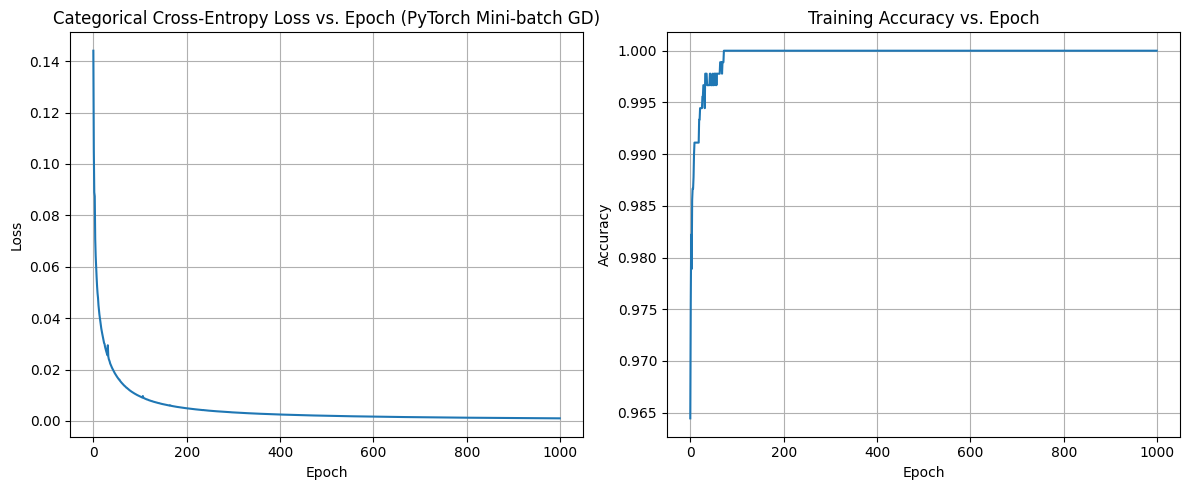

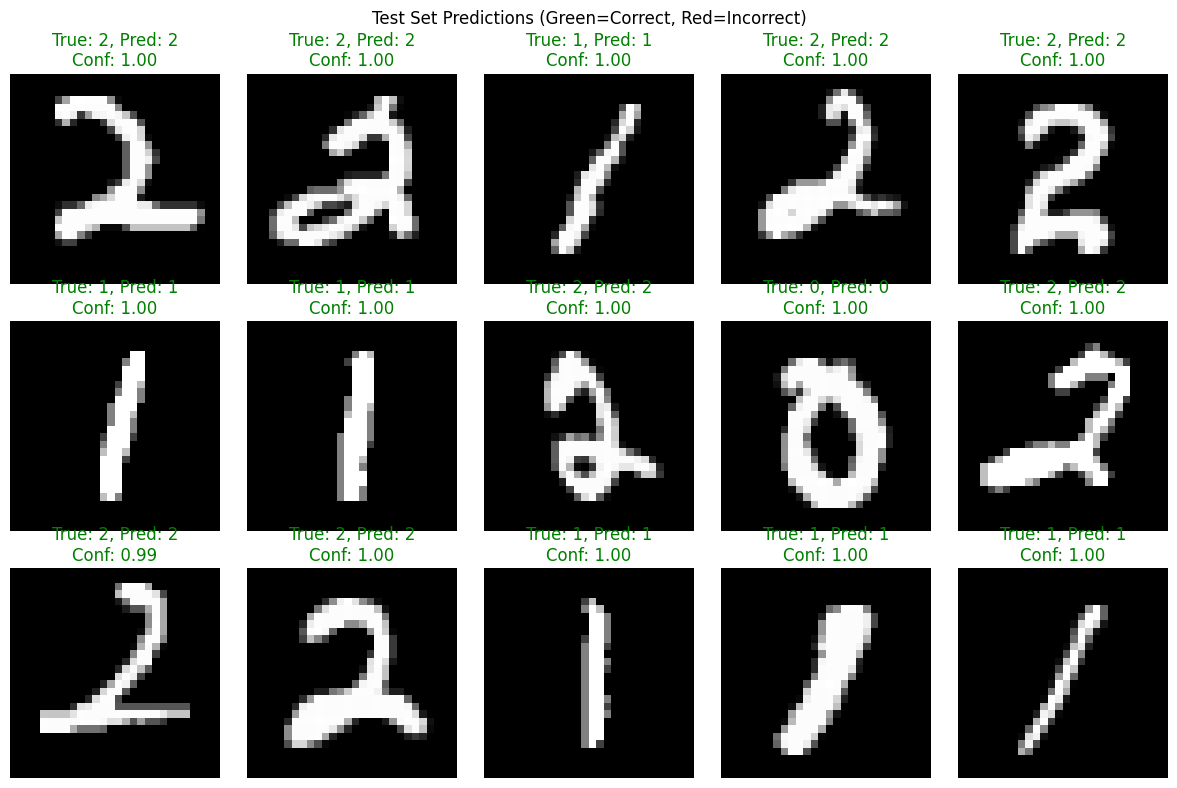


Probe point: MNIST image (flattened 784D vector)
Test index: 1287
Current prediction: 2
Target class (randomly chosen from other classes): 0
Current probabilities at probe: [3.6128527e-05 5.4313075e-13 9.9996388e-01]
Current prob for target class 0: 0.0000


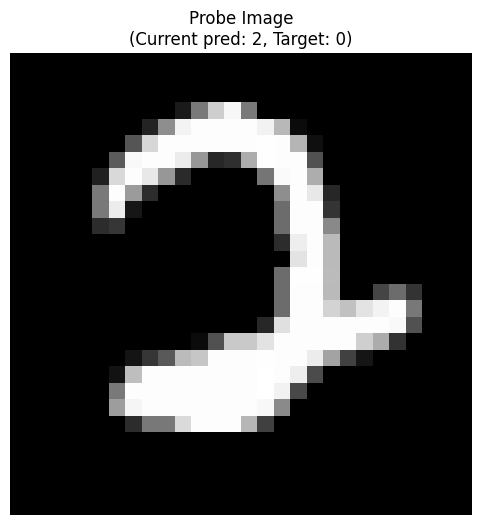

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import grad
from torchvision import datasets, transforms

B = 32  # batch size
RANDOM_SEED = 42

# Set device and reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Using device: {device}")

# ---- 1) Load real MNIST data ----
# Transform for MNIST: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download and load MNIST dataset
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# For this experiment, let's use a subset of MNIST with only 3 classes (0, 1, 2)
def filter_mnist_classes(dataset, classes=[0, 1, 2]):
    """Filter dataset to only include specified classes"""
    indices = []
    targets = []
    data = []
    
    for i, (img, label) in enumerate(dataset):
        if label in classes:
            indices.append(i)
            targets.append(classes.index(label))  # Remap to 0, 1, 2
            data.append(img.flatten())  # Flatten 28x28 to 784
    
    return torch.stack(data), torch.tensor(targets)

# Filter to 3 classes and take a subset for faster training
n_classes = 3
target_classes = [0, 1, 2]
X_train, y_train = filter_mnist_classes(train_dataset, target_classes)
X_test, y_test = filter_mnist_classes(test_dataset, target_classes)

# Take subset for demonstration (300 samples per class)
samples_per_class = 300
subset_indices = []
for class_idx in range(n_classes):
    class_mask = y_train == class_idx
    class_indices = torch.where(class_mask)[0][:samples_per_class]
    subset_indices.extend(class_indices.tolist())

subset_indices = torch.tensor(subset_indices)
X = X_train[subset_indices]
y = y_train[subset_indices]

# Shuffle the dataset
perm = torch.randperm(len(X))
X = X[perm]
y = y[perm]

N, D = X.shape  # D = 784 (28*28)

# Convert to device
X_tensor = X.to(device)
y_tensor = y.to(device)

print(f"Dataset: {N} samples, {D} features, {n_classes} classes")
print(f"Class distribution: {torch.bincount(y_tensor)}")
print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"Feature dimension (flattened images): {D}")

# Visualize some examples from each class
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for class_idx in range(n_classes):
    class_mask = y == class_idx
    class_samples = X[class_mask][:5]  # Take first 5 samples of each class
    
    for i in range(5):
        img = class_samples[i].reshape(28, 28)
        axes[class_idx, i].imshow(img, cmap='gray')
        axes[class_idx, i].set_title(f'Class {target_classes[class_idx]}')
        axes[class_idx, i].axis('off')

plt.suptitle('Sample MNIST Images from Training Set')
plt.tight_layout()
plt.show()

# ---- 2) Define PyTorch Multi-class Logistic Regression Model for MNIST ----
class MultiClassLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultiClassLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, num_classes)
        
        # Initialize with small weights for MNIST
        nn.init.normal_(self.linear.weight, mean=0, std=0.01)
        nn.init.zeros_(self.linear.bias)
    
    def forward(self, x):
        return self.linear(x)

# Create model for MNIST (784 -> 3 classes)
model = MultiClassLogisticRegression(D, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Initial parameters:")
print(f"Weight shape: {model.linear.weight.data.shape}")
print(f"Bias shape: {model.linear.bias.data.shape}")

# ---- 3) Training with mini-batch GD ----
epochs = 1000  # Reduced epochs for MNIST

loss_history = []
acc_history = []

# Create dataset and dataloader
dataset = TensorDataset(X_tensor, y_tensor)

for epoch in range(epochs):
    # Shuffle data each epoch
    indices = torch.randperm(N)
    X_epoch = X_tensor[indices]
    y_epoch = y_tensor[indices]
    
    # Mini-batch training
    for start in range(0, N, B):
        end = min(start + B, N)
        X_batch = X_epoch[start:end]
        y_batch = y_epoch[start:end]
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Track full-data loss and accuracy
    with torch.no_grad():
        full_outputs = model(X_tensor)
        full_loss = criterion(full_outputs, y_tensor)
        loss_history.append(full_loss.item())
        
        # Accuracy
        _, predicted = torch.max(full_outputs, 1)
        accuracy = (predicted == y_tensor).float().mean().item()
        acc_history.append(accuracy)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss_history[-1]:.4f}, Acc = {acc_history[-1]:.4f}")

# Final metrics
with torch.no_grad():
    final_outputs = model(X_tensor)
    _, predictions = torch.max(final_outputs, 1)
    accuracy = (predictions == y_tensor).float().mean().item()

print("\nLearned parameters (PyTorch mini-batch GD):")
print(f"Weight shape: {model.linear.weight.data.shape}")
print(f"Bias shape: {model.linear.bias.data.shape}")
print(f"Final CCE loss: {loss_history[-1]:.6f}")
print(f"Training Accuracy: {accuracy*100:.2f}%")

# Evaluate on test set
X_test_tensor = X_test.to(device)
y_test_tensor = y_test.to(device)

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    _, test_predictions = torch.max(test_outputs, 1)
    test_accuracy = (test_predictions == y_test_tensor).float().mean().item()

print(f"Test Loss: {test_loss.item():.6f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(loss_history)
ax1.set_title("Categorical Cross-Entropy Loss vs. Epoch (PyTorch Mini-batch GD)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(acc_history)
ax2.set_title("Training Accuracy vs. Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Visualize some test predictions
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
test_indices = torch.randperm(len(X_test))[:15]  # Random test samples

with torch.no_grad():
    for i, idx in enumerate(test_indices):
        row = i // 5
        col = i % 5
        
        img = X_test[idx].reshape(28, 28)
        true_label = target_classes[y_test[idx]]
        
        # Get model prediction
        pred_logits = model(X_test[idx].unsqueeze(0).to(device))
        pred_probs = F.softmax(pred_logits, dim=1)[0]
        pred_class = torch.argmax(pred_probs).item()
        pred_label = target_classes[pred_class]
        confidence = pred_probs[pred_class].item()
        
        axes[row, col].imshow(img, cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.2f}', 
                                color=color)
        axes[row, col].axis('off')

plt.suptitle('Test Set Predictions (Green=Correct, Red=Incorrect)')
plt.tight_layout()
plt.show()

# Store original parameters for later use
w_orig = model.linear.weight.data.clone()
b_orig = model.linear.bias.data.clone()

# ---- Probe (x*, y*) ----
# Randomly select a probe point from test set based on RANDOM_SEED
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Random test sample as probe
test_idx = torch.randint(0, len(X_test), (1,)).item()
x_star = X_test[test_idx].to(device)  # This is a real MNIST image (flattened)

# Get current prediction
with torch.no_grad():
    logits_star = model(x_star.unsqueeze(0))
    probs_star = F.softmax(logits_star, dim=1)[0]
    current_pred = torch.argmax(probs_star).item()

# Randomly select target class from classes that are NOT the current prediction
other_classes = [c for c in range(n_classes) if c != current_pred]
class_star = np.random.choice(other_classes)

print(f"\nProbe point: MNIST image (flattened 784D vector)")
print(f"Test index: {test_idx}")
print(f"Current prediction: {current_pred}")
print(f"Target class (randomly chosen from other classes): {class_star}")
print(f"Current probabilities at probe: {probs_star.cpu().numpy()}")
print(f"Current prob for target class {class_star}: {probs_star[class_star].item():.4f}")

# Visualize the probe image
plt.figure(figsize=(6, 6))
probe_image = x_star.cpu().numpy().reshape(28, 28)
plt.imshow(probe_image, cmap='gray')
plt.title(f'Probe Image\n(Current pred: {current_pred}, Target: {class_star})')
plt.axis('off')
plt.show()

# Influence pipeline: IHVP via CG + Cross-Jacobian–Vector product (double-backward)

We compute

$
G_\delta \;=\; -\frac{1}{n}\,\big[\nabla_z \nabla_\theta L(z,\hat\theta)\big]^\top \underbrace{(H_{\hat\theta}+\lambda I)^{-1}\nabla_\theta f(\hat\theta)}_{v}
$

* IHVP $v$ is solved by **conjugate gradient** on the empirical-risk Hessian using **HVPs**.
* $J^\top v = [\nabla_z \nabla_\theta L]^\top v = \nabla_z\big(\nabla_\theta L \cdot v\big)$ via **one** double-backward per batch.
* Here, $z\equiv x$ (labels are fixed). For NLP, replace `x` by token **embeddings**.



In [2]:

def params_of(model):
    return [p for p in model.parameters() if p.requires_grad]

def flatten_list(tensors):
    return torch.cat([t.reshape(-1) for t in tensors])

def unflatten_like(flat_vec, like_tensors):
    out, i = [], 0
    for t in like_tensors:
        n = t.numel()
        out.append(flat_vec[i:i+n].view_as(t))
        i += n
    return out

num_params = sum(p.numel() for p in params_of(model))
print(f"#params: {num_params}")

#params: 2355



## 1) Define the query observable $f(\theta)=\log p(y^\*|x^\*;\theta)$ and compute $g_f=\nabla_\theta f$

We’ll take the **probe** `(x_star, class_star)` you created, and compute the gradient w.r.t. parameters.


In [3]:

def grad_theta_f_logprob(model, x_star, y_star):
    """
    ∇_θ f where f = log p(y*=y_star | x*=x_star; θ)
    Returns a list matching model.parameters().
    """
    model.eval()
    params = params_of(model)

    # Ensure params track gradients for autograd
    req_prev = [p.requires_grad for p in params]
    for p in params: p.requires_grad_(True)

    logits = model(x_star.unsqueeze(0))            # [1, K]
    logp = F.log_softmax(logits, dim=-1)[0, y_star]  # scalar
    g_list = torch.autograd.grad(logp, params, retain_graph=False, create_graph=False)

    # restore requires_grad
    for p, r in zip(params, req_prev): p.requires_grad_(r)
    return [g.detach() for g in g_list]

g_f_list = grad_theta_f_logprob(model, x_star, class_star)
g_f_flat = flatten_list(g_f_list)
print("||∇θ f||:", g_f_flat.norm().item())

||∇θ f||: 44.80949020385742



##2) Hessian–Vector Product (HVP) for the empirical risk

We implement $ H v = \nabla_\theta^2 \Big(\frac{1}{N}\sum_i \ell_i(\theta)\Big)\, v $.

**Note:** We average the loss over the **full training set** in mini-batches to keep memory small.
Add **damping** $\lambda v$ inside the HVP during CG.

In [4]:
from contextlib import nullcontext

def hvp_empirical_risk(model, data_X, data_y, v_list, batch_size=256):
    """
    Compute H v where H is the Hessian of mean cross-entropy over (data_X, data_y).
    v_list is a list shaped like model.parameters().
    """
    model.eval()
    params = params_of(model)
    # Save and set requires_grad for higher-order derivs
    req_prev = [p.requires_grad for p in params]
    for p in params: p.requires_grad_(True)

    # running sum of HVP; we'll average at the end
    hvp_sum = [torch.zeros_like(p) for p in params]

    N_total = data_X.shape[0]
    for start in range(0, N_total, batch_size):
        end = min(start + batch_size, N_total)
        xb = data_X[start:end]
        yb = data_y[start:end]

        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction='mean')  # mean over batch for stability

        # First grad: g = ∇θ loss
        g_list = torch.autograd.grad(loss, params, create_graph=True)

        # Dot with v: s = g·v
        s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

        # Second grad: ∇θ s = H v (on this batch)
        hvp_batch = torch.autograd.grad(s, params, retain_graph=False)
        for acc, h in zip(hvp_sum, hvp_batch):
            acc += h.detach()

        # Free the graph for this batch
        del g_list, s, hvp_batch

    # Average across all batches (note loss was mean per batch; here we average per-batch HVPs)
    num_batches = (N_total + batch_size - 1) // batch_size
    hvp_avg = [h / num_batches for h in hvp_sum]

    # restore original requires_grad flags
    for p, r in zip(params, req_prev): p.requires_grad_(r)
    return hvp_avg

##3) Conjugate gradient solver to obtain the IHVP

We solve $(H+\lambda I) v = b$ for $v$, where $b=\nabla_\theta f$.
Each CG iteration uses **one HVP** (plus damping).

In [5]:
def cg_solve_ihvp(model, data_X, data_y, b_list, damping=1e-3, tol=1e-6, max_iter=200, batch_size=256, verbose=False):
    """
    Conjugate gradient on (H + λI) v = b.
    Returns list of tensors v_list matching params.
    """
    params = params_of(model)

    def apply_A(v_list):
        Hv = hvp_empirical_risk(model, data_X, data_y, v_list, batch_size=batch_size)
        # Add damping: (H + λ I) v
        return [h + damping * v for h, v in zip(Hv, v_list)]

    # Initialize
    v_list = [torch.zeros_like(p) for p in params]
    r_list = [b.clone() for b in b_list]                     # r = b - A*0 = b
    p_list = [r.clone() for r in r_list]                     # p = r
    rTr = sum((r*r).sum() for r in r_list)

    if verbose:
        print(f"CG iter 0: ||r||={rTr.sqrt().item():.4e}")

    for it in range(1, max_iter+1):
        Ap = apply_A(p_list)
        pAp = sum((p*a).sum() for p, a in zip(p_list, Ap))
        alpha = rTr / (pAp + 1e-12)
        # v += alpha * p; r -= alpha * A p
        for i in range(len(v_list)):
            v_list[i] = v_list[i] + alpha * p_list[i]
            r_list[i] = r_list[i] - alpha * Ap[i]

        rTr_new = sum((r*r).sum() for r in r_list)
        if verbose and (it % 10 == 0 or it == 1):
            print(f"CG iter {it}: ||r||={rTr_new.sqrt().item():.4e}")

        if rTr_new.sqrt() < tol:
            if verbose:
                print(f"CG converged in {it} iterations.")
            break

        beta = rTr_new / (rTr + 1e-12)
        for i in range(len(p_list)):
            p_list[i] = r_list[i] + beta * p_list[i]
        rTr = rTr_new

    return v_list

##4) Compute the IHVP for our probe

This yields $v \approx (H+\lambda I)^{-1}\nabla_\theta f$.  
You can later **swap this CG block** with your **EK‑FAC** `.ihvp(...)` call.


In [6]:
damping = 5e-3    # Tikhonov damping (tune as needed)
cg_tol = 1e-5
cg_max_iter = 200

with torch.no_grad():
    # Work on TRAIN set curvature
    b_list = [g.clone() for g in g_f_list]   # b = ∇θ f

# Run CG
v_list = cg_solve_ihvp(
    model, X_tensor, y_tensor, b_list,
    damping=damping, tol=cg_tol, max_iter=cg_max_iter, batch_size=256, verbose=True
)

v_flat = flatten_list(v_list)
print("||v||:", v_flat.norm().item())

CG iter 0: ||r||=4.4809e+01
CG iter 1: ||r||=5.2211e+01
CG iter 10: ||r||=1.5251e+00
CG iter 20: ||r||=4.7913e-03
CG iter 30: ||r||=7.3574e-05
CG converged in 35 iterations.
||v||: 4696.2265625



##5) Cross-Jacobian–vector product: $J^\top v = [\nabla_x \nabla_\theta L(x,\hat\theta)]^\top v$

For a batch $(x,y)$, we compute:

$
J^\top v \;=\; \nabla_x \big( \nabla_\theta L(x,y;\hat\theta)^\top v \big)
$

using a single **double-backward**. Then
$
G_\delta(x) \;=\; -\frac{1}{n}\,J^\top v.
$

In [7]:

def Jt_v_batch_inputs(model, x_batch, y_batch, v_list):
    """
    Returns J^T v for each input in x_batch
    where J = ∇_x ∇_θ L(x,y; θ).
    """
    params = params_of(model)
    model.eval()

    x_batch = x_batch.detach().requires_grad_(True)
    logits = model(x_batch)
    # Sum the per-example losses so grads add linearly and remain per-example separable
    loss = F.cross_entropy(logits, y_batch, reduction='sum')

    # First grad wrt θ
    g_list = torch.autograd.grad(loss, params, create_graph=True)

    # s = g^T v (scalar)
    s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))

    # J^T v = ∇_x s
    Jt_v = torch.autograd.grad(s, x_batch, retain_graph=False, create_graph=False)[0]
    return Jt_v  # shape [B, D]

def G_delta_batch(model, x_batch, y_batch, v_list, n_train):
    Jt_v = Jt_v_batch_inputs(model, x_batch, y_batch, v_list)
    return -(1.0 / n_train) * Jt_v


### 6) Compute $G_\delta$ for a candidate batch (training points) and visualize for one example


G_delta shape: torch.Size([16, 784])


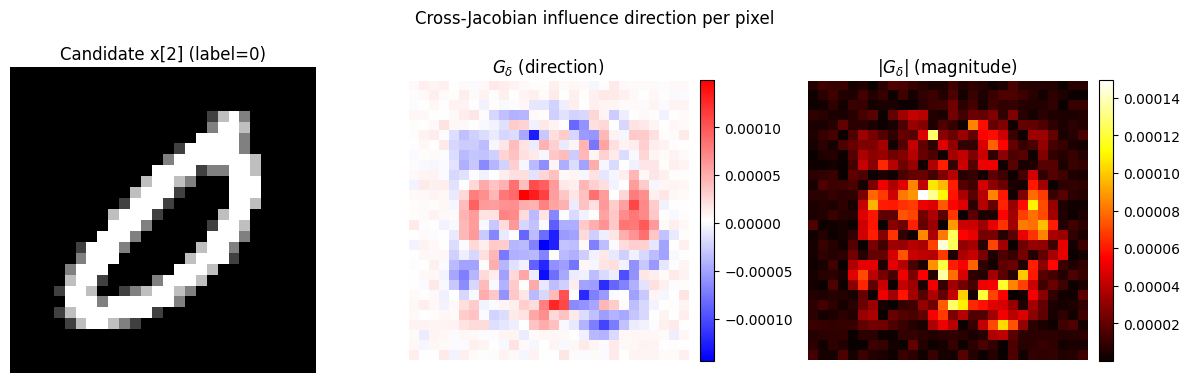

In [8]:
# Take a small batch of training points as "candidates"
cand_B = 16
cand_x = X_tensor[:cand_B]
cand_y = y_tensor[:cand_B]

G_delta = G_delta_batch(model, cand_x, cand_y, v_list, n_train=N)   # [B, 784]
print("G_delta shape:", G_delta.shape)

# Visualize for the first candidate
k = 2
g_img = G_delta[k].detach().cpu().reshape(28, 28)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(cand_x[k].cpu().reshape(28,28), cmap='gray')
plt.title(f"Candidate x[{k}] (label={target_classes[cand_y[k].item()]})")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(g_img, cmap='bwr')
plt.title(r"$G_\delta$ (direction)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(g_img.abs(), cmap='hot')
plt.title(r"$|G_\delta|$ (magnitude)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')
plt.suptitle("Cross-Jacobian influence direction per pixel")
plt.tight_layout()
plt.show()


##7) (Optional) Apply a small step to a candidate image along $ \mathrm{sign}(G_\delta) $

We’ll demonstrate that nudging a **training example** $x$ along $G_\delta$ changes the probe’s target log-prob as predicted by the theory.

For demonstration we’ll apply the step to a **single** training point and recompute the model’s parameters by one Newton-style update approximation:

\[
\Delta\hat\theta \approx -\frac{1}{n}\, H^{-1}\,\big[\nabla_x\nabla_\theta L(x,\hat\theta)\big]\,\delta 
\;=\;
\frac{1}{n}\, v \,\underbrace{(J^\top\delta)}_{\text{scalar via inner product}}
\]

Instead of retraining the model, we approximate the parameter change along $v$ scaled by $J^\top \delta$.


In [9]:



# %%
# Choose a candidate and an input step
alpha = 0.5  # step size in input space (tune small ~ [0.1, 1.0])
cand_idx = 0
x0 = cand_x[cand_idx].detach()
y0 = cand_y[cand_idx].detach()

G0 = G_delta[cand_idx]  # [D]
delta = alpha * G0.sign()  # FGSM-style step

# Compute scalar factor s = (J^T v)·delta  (note: J^T v is G0 * (-n), but we already have G0 = -(1/n) J^T v)
# So J^T v = -n * G0, and (J^T v)·delta = (-n) * (G0·delta)
s_scalar = (-N) * torch.dot(G0.detach(), delta.detach()).item()

# Parameter update approximation along v
# Δθ ≈ (1/n) * v * s_scalar  (derivation above)
delta_theta_flat = (1.0 / N) * s_scalar * flatten_list(v_list)
delta_theta = unflatten_like(delta_theta_flat, params_of(model))

# Backup params
with torch.no_grad():
    w_backup = [p.detach().clone() for p in params_of(model)]

# Apply parameter delta (approximate updated model)
with torch.no_grad():
    for p, d in zip(params_of(model), delta_theta):
        p += d

# Evaluate probe log-prob before/after
with torch.no_grad():
    logits_before = model(x_star.unsqueeze(0))
    logp_before = F.log_softmax(logits_before, dim=-1)[0, class_star].item()

# Restore original params, then apply the *input* change (to the candidate) and retrace the same approximation
# For clarity in this demo, we just report the "predicted" change based on the linearized formula.
# (A true end-to-end test would re-train or re-fit, which we avoid here.)

# Restore original params
with torch.no_grad():
    for p, b in zip(params_of(model), w_backup):
        p.copy_(b)

print(f"Predicted Δ log p(y*|x*): {(1.0/N) * s_scalar:.6f} (linearized)")
print(f"Log p(y*|x*) after approximate Δθ applied: {logp_before:.6f}  (evaluated with Δθ)")


Predicted Δ log p(y*|x*): -0.000598 (linearized)
Log p(y*|x*) after approximate Δθ applied: -97.314835  (evaluated with Δθ)




 %% [markdown]
  8) Batch scoring / ranking candidates by influence
 
 For many use cases you only need **scores** $v^\top \nabla_\theta L(x,y)$ to rank candidates.
 That avoids the double-backward entirely and costs ~**1 backward per batch**.



In [10]:


# %%
def batch_influence_scores(model, x_batch, y_batch, v_list):
    """
    Returns influence scores v^T ∇θ L(x_i, y_i) for each example i in the batch.
    Uses per-sample gradients via a trick with a weighted sum.
    For exact per-sample grads, consider functorch/backpack; here we do
    a simple approximation by splitting into micro-batches of size 1.
    """
    params = params_of(model)
    scores = []
    for i in range(x_batch.size(0)):
        xb = x_batch[i:i+1].detach()
        yb = y_batch[i:i+1].detach()
        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction='sum')
        g_list = torch.autograd.grad(loss, params, retain_graph=False, create_graph=False)
        s = sum((gi * vi).sum() for gi, vi in zip(g_list, v_list))
        scores.append(s.item())
    return np.array(scores)

# Example: score first 64 training points
cand_x2 = X_tensor[:64]
cand_y2 = y_tensor[:64]
scores = batch_influence_scores(model, cand_x2, cand_y2, v_list)
topk = scores.argsort()[::-1][:10]
print("Top-10 most positive v^T ∇θ L(x):", topk)
print("Scores:", scores[topk])



Top-10 most positive v^T ∇θ L(x): [42 57 60 25 29 44 20 62 16 49]
Scores: [25.9265728  13.13494873  7.40755939  3.1650424   1.74418008  1.27245748
  1.11108339  0.83109546  0.69270724  0.65652221]


# Visualization: Dimensionality Reduction & Decision Boundaries

We'll use t-SNE to reduce the 784-dimensional MNIST data to 2D and visualize:
1. How MNIST points cluster by class
2. The perturbations applied to training points
3. How the decision boundary changes after perturbation

Reducing dimensions with PCA then t-SNE...
t-SNE embedding shape: (900, 2)
Explained variance by first 50 PCA components: 88.07%


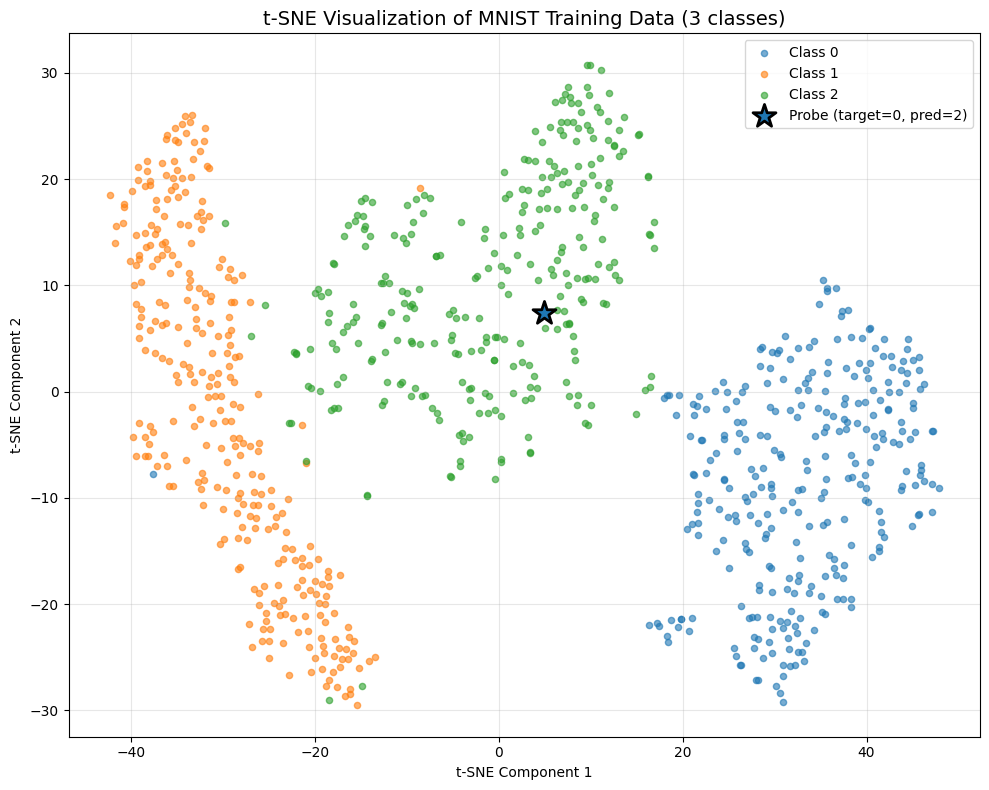

In [11]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# First, reduce dimensions using PCA to speed up t-SNE
print("Reducing dimensions with PCA then t-SNE...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X.cpu().numpy())

# Then apply t-SNE for final 2D visualization
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_pca)

print(f"t-SNE embedding shape: {X_2d.shape}")
print(f"Explained variance by first 50 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

# Get probe's current prediction
with torch.no_grad():
    probe_logits = model(x_star.unsqueeze(0))
    probe_pred_class = torch.argmax(probe_logits, dim=1).item()

# Visualize the clustering
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               c=colors[i], label=f'Class {target_classes[i]}', 
               alpha=0.6, s=20)

# Add probe point (using nearest neighbor approximation)
x_star_pca_initial = pca.transform(x_star.cpu().numpy().reshape(1, -1))
from scipy.spatial.distance import cdist
distances_init = cdist(x_star_pca_initial, X_pca, metric='euclidean')
nearest_idx_init = np.argmin(distances_init)
x_star_2d_initial = X_2d[nearest_idx_init]

# Color by target class
probe_color = colors[class_star]
plt.scatter(x_star_2d_initial[0], x_star_2d_initial[1], c=probe_color, marker='*', 
           s=300, edgecolors='black', linewidths=2, 
           label=f'Probe (target={class_star}, pred={probe_pred_class})', zorder=15)

plt.title('t-SNE Visualization of MNIST Training Data (3 classes)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Compute perturbations and visualize their effect

Now let's compute adversarial perturbations on a batch of training points using the influence function approach, then visualize how these perturbations affect the data distribution and decision boundary in the 2D embedding space.

In [12]:
# Compute perturbations for a batch of points using PGD
EPSILON = 2.0      # L-inf perturbation budget (scaled for normalized MNIST)
ALPHA = 0.3        # Step size for PGD
P_NORM = "inf"     # "inf" or "2"
N_STEPS = 20       # Number of PGD steps
BATCH_SIZE = 64    # Number of points to perturb

# Select a batch of training points to perturb
torch.manual_seed(42)
perm_vis = torch.randperm(N)
S_idx = perm_vis[:BATCH_SIZE]

print(f"Perturbing {BATCH_SIZE} training points...")
print(f"Perturbation budget: ε={EPSILON} (L-{P_NORM} norm)")

# Projection operators
def proj_linf(x0, x_candidate, eps):
    return torch.clamp(x_candidate, x0 - eps, x0 + eps)

def proj_l2(x0, x_candidate, eps):
    d = x_candidate - x0
    n = torch.norm(d.reshape(d.shape[0], -1), p=2, dim=1, keepdim=True)
    scale = torch.clamp(eps / (n + 1e-12), max=1.0)
    return x0 + d * scale.reshape(-1, *([1]*(d.ndim-1)))

# Initialize adversarial examples
X0_batch = X_tensor[S_idx].clone()
y_batch = y_tensor[S_idx]
X_adv = X0_batch.clone()

# Store trajectory for visualization
X_trajectory = [X_adv.cpu().numpy().copy()]

# PGD iterations
for step in range(N_STEPS):
    # Compute G_delta for current batch
    G_delta_current = G_delta_batch(model, X_adv, y_batch, v_list, n_train=N)
    
    # PGD step for each example
    if P_NORM == "inf":
        step_vec = ALPHA * torch.sign(G_delta_current)
        cand = X_adv + step_vec
        X_adv = proj_linf(X0_batch, cand, EPSILON)
    else:  # L2
        gnorm = torch.norm(G_delta_current.reshape(BATCH_SIZE, -1), p=2, dim=1, keepdim=True) + 1e-12
        step_vec = ALPHA * (G_delta_current / gnorm.reshape(-1, 1))
        cand = X_adv + step_vec
        X_adv = proj_l2(X0_batch, cand, EPSILON)
    
    # Store trajectory every 5 steps
    if (step + 1) % 5 == 0:
        X_trajectory.append(X_adv.cpu().numpy().copy())

print(f"Generated {len(X_trajectory)} snapshots of perturbation trajectory")

# Compute perturbation norms
pert_norms = torch.norm((X_adv - X0_batch).reshape(BATCH_SIZE, -1), p=float('inf') if P_NORM=='inf' else 2, dim=1)
print(f"Perturbation norms - mean: {pert_norms.mean():.4f}, max: {pert_norms.max():.4f}")

Perturbing 64 training points...
Perturbation budget: ε=2.0 (L-inf norm)
Generated 5 snapshots of perturbation trajectory
Perturbation norms - mean: 2.0000, max: 2.0000


## Visualize perturbation trajectory in 2D embedding space

Project the original points and their perturbations into the same t-SNE space to see how the adversarial examples move through the feature space.

In [13]:
# Project perturbed points into the same PCA space, then t-SNE
X_adv_pca = pca.transform(X_adv.cpu().numpy())

# For visualization, we'll create a combined dataset with original + all trajectory points
# This ensures consistent embedding
all_points = [X_pca]  # Original data in PCA space
for traj_point in X_trajectory:
    all_points.append(pca.transform(traj_point))

X_combined_pca = np.vstack(all_points)

# Apply t-SNE to combined data for consistent embedding
print("Computing t-SNE embedding for original + perturbed data...")
tsne_combined = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000)
X_combined_2d = tsne_combined.fit_transform(X_combined_pca)

# Split back into original and trajectory points
n_orig = len(X_pca)
X_2d_vis = X_combined_2d[:n_orig]  # Original data
trajectory_2d = []
idx = n_orig
for i in range(len(X_trajectory)):
    n_batch = len(X_trajectory[i])
    trajectory_2d.append(X_combined_2d[idx:idx+n_batch])
    idx += n_batch

print(f"Created 2D embedding with {len(trajectory_2d)} trajectory snapshots")

# Project probe point to 2D space using the same transformations
x_star_pca = pca.transform(x_star.cpu().numpy().reshape(1, -1))
# For probe, we need to include it in the t-SNE fit or use an approximate mapping
# Since t-SNE doesn't support transform on new points, we'll find nearest neighbor
from scipy.spatial.distance import cdist
distances = cdist(x_star_pca, X_pca, metric='euclidean')
nearest_idx = np.argmin(distances)
x_star_2d = X_2d_vis[nearest_idx]  # Approximate position based on nearest neighbor in PCA space

# Get probe's current prediction
with torch.no_grad():
    probe_logits = model(x_star.unsqueeze(0))
    probe_pred_class = torch.argmax(probe_logits, dim=1).item()

print(f"Probe point projected to 2D (nearest neighbor approximation)")
print(f"Probe target class: {class_star}, Current prediction: {probe_pred_class}")
print(f"Probe 2D position: {x_star_2d}")
print(f"Note: Probe is colored by TARGET class ({class_star}), not prediction")

Computing t-SNE embedding for original + perturbed data...
Created 2D embedding with 5 trajectory snapshots
Probe point projected to 2D (nearest neighbor approximation)
Probe target class: 0, Current prediction: 2
Probe 2D position: [-0.854421 -6.841115]
Note: Probe is colored by TARGET class (0), not prediction


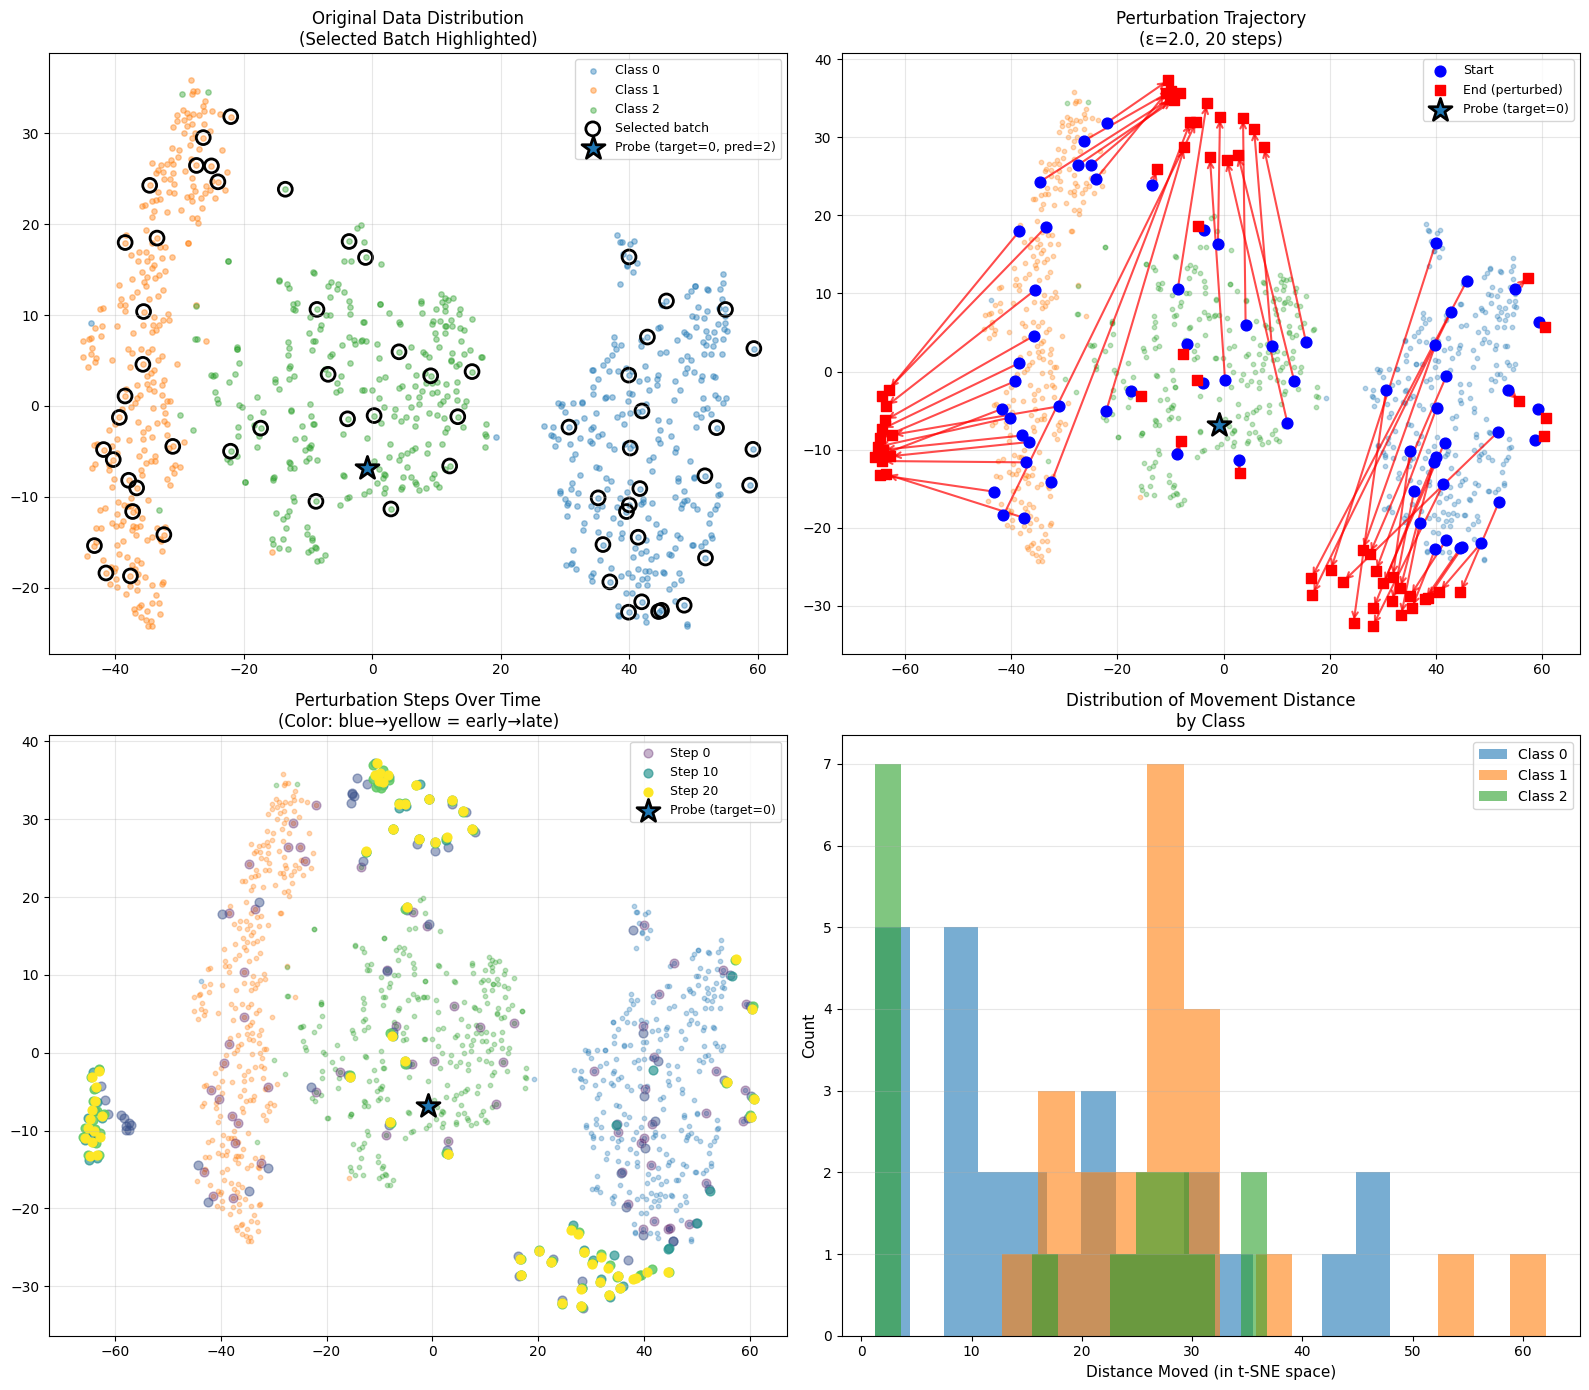


Movement statistics:
  Mean distance: 21.399
  Max distance: 62.110
  Min distance: 1.264

Probe info:
  Target class: 0
  Current prediction: 2
  Probe colored by: TARGET class (not prediction)


In [14]:
# Visualize the perturbation trajectory
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Get indices in 2D space
S_idx_cpu = S_idx.cpu().numpy()

# Get probe's current prediction
with torch.no_grad():
    probe_logits = model(x_star.unsqueeze(0))
    probe_pred_class = torch.argmax(probe_logits, dim=1).item()

# Probe color based on TARGET class (not prediction)
probe_color = colors[class_star]

# Plot 1: Original clustering with selected batch highlighted
ax = axes[0, 0]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], label=f'Class {target_classes[i]}', 
              alpha=0.4, s=15)

# Highlight selected batch
ax.scatter(X_2d_vis[S_idx_cpu, 0], X_2d_vis[S_idx_cpu, 1],
          facecolors='none', edgecolors='black', s=100, linewidths=2,
          label='Selected batch')

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0], x_star_2d[1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star}, pred={probe_pred_class})', zorder=15)

ax.set_title('Original Data Distribution\n(Selected Batch Highlighted)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Perturbation trajectory with arrows
ax = axes[0, 1]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], alpha=0.3, s=10)

# Draw arrows showing movement
for i in range(len(S_idx_cpu)):
    start = trajectory_2d[0][i]  # First position
    end = trajectory_2d[-1][i]   # Final position
    ax.annotate('', xy=end, xytext=start,
               arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7))

# Plot start and end positions
ax.scatter(trajectory_2d[0][:, 0], trajectory_2d[0][:, 1],
          c='blue', s=60, marker='o', label='Start', zorder=5)
ax.scatter(trajectory_2d[-1][:, 0], trajectory_2d[-1][:, 1],
          c='red', s=60, marker='s', label='End (perturbed)', zorder=5)

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0], x_star_2d[1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star})', zorder=15)

ax.set_title(f'Perturbation Trajectory\n(ε={EPSILON}, {N_STEPS} steps)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Show intermediate steps
ax = axes[1, 0]
for i in range(n_classes):
    mask = y.cpu().numpy() == i
    ax.scatter(X_2d_vis[mask, 0], X_2d_vis[mask, 1], 
              c=colors[i], alpha=0.3, s=10)

# Plot trajectory with color gradient
n_traj = len(trajectory_2d)
cmap = plt.cm.viridis
for t_idx, traj_point in enumerate(trajectory_2d):
    alpha_val = 0.3 + 0.7 * (t_idx / (n_traj - 1))
    color_val = cmap(t_idx / (n_traj - 1))
    ax.scatter(traj_point[:, 0], traj_point[:, 1],
              c=[color_val], s=40, alpha=alpha_val, 
              label=f'Step {t_idx*5}' if t_idx % 2 == 0 else '')

# Add probe point (colored by TARGET class)
ax.scatter(x_star_2d[0], x_star_2d[1], c=probe_color, marker='*', 
          s=300, edgecolors='black', linewidths=2, 
          label=f'Probe (target={class_star})', zorder=15)

ax.set_title('Perturbation Steps Over Time\n(Color: blue→yellow = early→late)', fontsize=12)
if n_traj <= 6:
    ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Distance moved in embedding space
ax = axes[1, 1]
distances = []
for i in range(len(S_idx_cpu)):
    dist = np.linalg.norm(trajectory_2d[-1][i] - trajectory_2d[0][i])
    distances.append(dist)

batch_labels = y_batch.cpu().numpy()
for i in range(n_classes):
    mask = batch_labels == i
    if mask.sum() > 0:
        ax.hist(np.array(distances)[mask], bins=15, alpha=0.6, 
               label=f'Class {target_classes[i]}', color=colors[i])

ax.set_xlabel('Distance Moved (in t-SNE space)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Movement Distance\nby Class', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nMovement statistics:")
print(f"  Mean distance: {np.mean(distances):.3f}")
print(f"  Max distance: {np.max(distances):.3f}")
print(f"  Min distance: {np.min(distances):.3f}")
print(f"\nProbe info:")
print(f"  Target class: {class_star}")
print(f"  Current prediction: {probe_pred_class}")
print(f"  Probe colored by: TARGET class (not prediction)")

## Decision Boundary Visualization

Visualize how the decision boundaries change after retraining on perturbed data. We'll train a simple classifier on the 2D t-SNE embeddings to approximate the decision regions.

In [15]:
# Train classifiers on 2D embeddings to visualize decision boundaries
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.preprocessing import StandardScaler

# Prepare data
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d_vis)
y_np = y.cpu().numpy()

# Train classifier on original 2D embeddings
clf_original = SklearnLR(max_iter=1000, multi_class='multinomial')
clf_original.fit(X_2d_scaled, y_np)

# Create perturbed dataset in 2D
X_pert_full = X_tensor.clone()
X_pert_full[S_idx] = X_adv

# Project perturbed full dataset to 2D
X_pert_pca = pca.transform(X_pert_full.cpu().numpy())
tsne_pert = TSNE(n_components=2, random_state=RANDOM_SEED+1, perplexity=30, n_iter=1000)
X_pert_2d = tsne_pert.fit_transform(X_pert_pca)

# Train classifier on perturbed 2D embeddings
X_pert_2d_scaled = scaler.fit_transform(X_pert_2d)
clf_perturbed = SklearnLR(max_iter=1000, multi_class='multinomial')
clf_perturbed.fit(X_pert_2d_scaled, y_np)

print(f"Original classifier accuracy (2D): {clf_original.score(X_2d_scaled, y_np):.3f}")
print(f"Perturbed classifier accuracy (2D): {clf_perturbed.score(X_pert_2d_scaled, y_np):.3f}")

Original classifier accuracy (2D): 0.979
Perturbed classifier accuracy (2D): 0.959


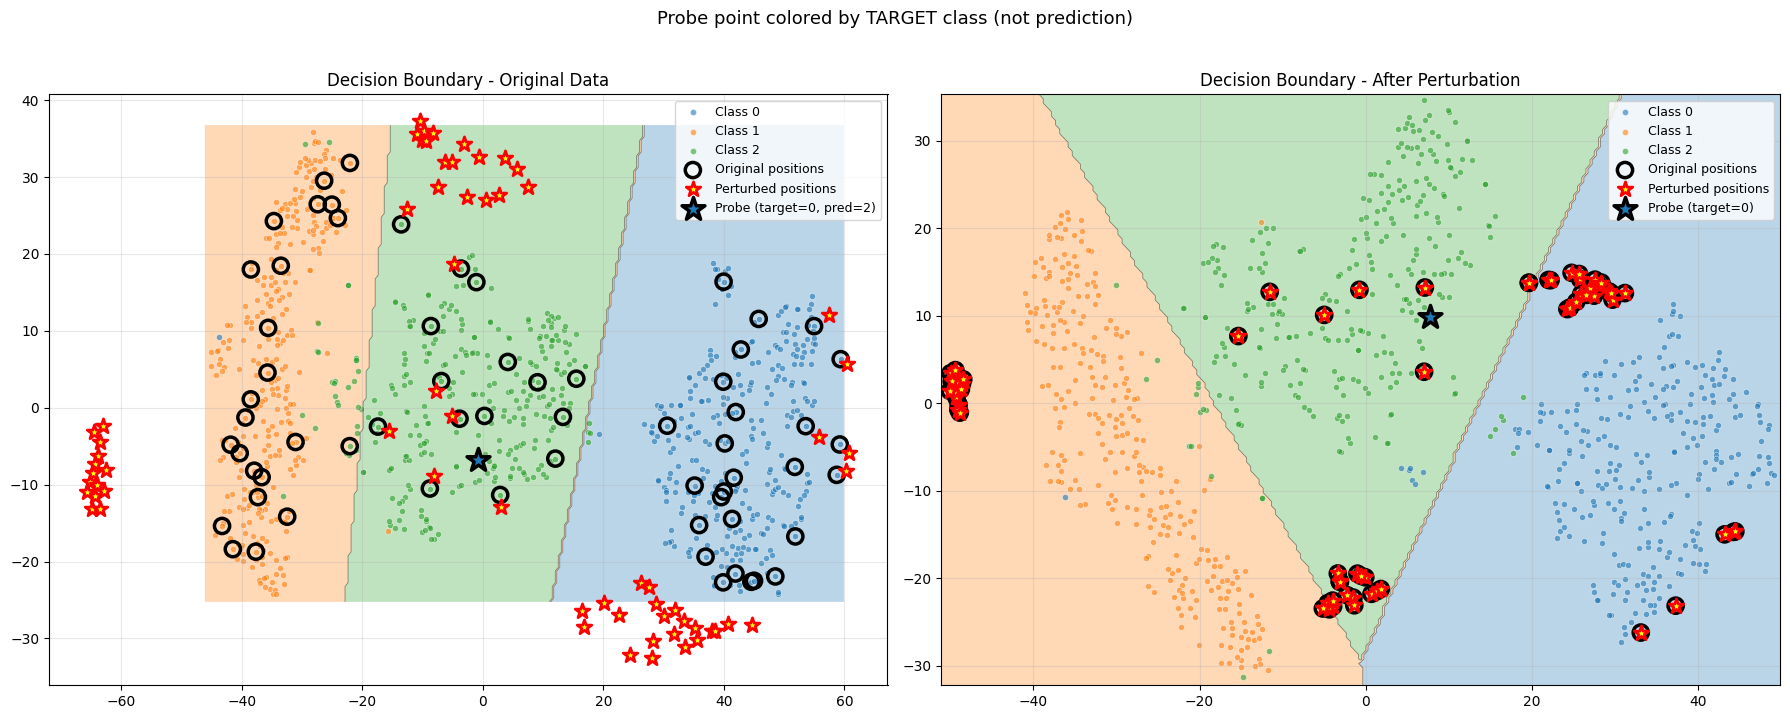

In [16]:
# Visualize decision boundaries
def plot_decision_boundary(ax, clf, X_2d, y_data, title, S_indices=None, X_adv_2d=None, 
                          probe_point=None, probe_target_class=None, probe_pred_class=None):
    """Plot decision boundary with data points"""
    # Create mesh
    h = 0.5  # step size in the mesh
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_scaled = scaler.transform(mesh_points)
    Z = clf.predict(mesh_scaled)
    Z = Z.reshape(xx.shape)
    
    # Plot decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(n_classes+1)-0.5, 
               colors=colors, antialiased=True)
    ax.contour(xx, yy, Z, alpha=0.5, levels=np.arange(n_classes+1)-0.5,
              colors='black', linewidths=0.5)
    
    # Plot data points
    for i in range(n_classes):
        mask = y_data == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                  c=colors[i], label=f'Class {target_classes[i]}',
                  alpha=0.6, s=20, edgecolors='white', linewidths=0.5)
    
    # Highlight perturbed points if provided
    if S_indices is not None and X_adv_2d is not None:
        ax.scatter(X_2d[S_indices, 0], X_2d[S_indices, 1],
                  facecolors='none', edgecolors='black', s=120, linewidths=2.5,
                  label='Original positions', zorder=10)
        ax.scatter(X_adv_2d[:, 0], X_adv_2d[:, 1],
                  c='yellow', edgecolors='red', s=120, linewidths=2,
                  marker='*', label='Perturbed positions', zorder=11)
    
    # Add probe point if provided (colored by TARGET class)
    if probe_point is not None and probe_target_class is not None:
        probe_color = colors[probe_target_class]
        if probe_pred_class is not None:
            label_text = f'Probe (target={probe_target_class}, pred={probe_pred_class})'
        else:
            label_text = f'Probe (target={probe_target_class})'
        ax.scatter(probe_point[0], probe_point[1], c=probe_color, marker='*', 
                  s=300, edgecolors='black', linewidths=2.5, 
                  label=label_text, zorder=15)
    
    ax.set_title(title, fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# Get probe's current prediction
with torch.no_grad():
    probe_logits_orig = model(x_star.unsqueeze(0))
    probe_pred_class_orig = torch.argmax(probe_logits_orig, dim=1).item()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Original decision boundary
plot_decision_boundary(axes[0], clf_original, X_2d_vis, y_np, 
                       'Decision Boundary - Original Data',
                       S_indices=S_idx_cpu, 
                       X_adv_2d=trajectory_2d[-1],
                       probe_point=x_star_2d,
                       probe_target_class=class_star,
                       probe_pred_class=probe_pred_class_orig)

# Perturbed decision boundary
S_idx_pert = S_idx_cpu  # Same indices
X_adv_pert_2d = X_pert_2d[S_idx_pert]

# Project probe to perturbed space (using nearest neighbor approximation)
from scipy.spatial.distance import cdist
X_pert_pca_probe = pca.transform(x_star.cpu().numpy().reshape(1, -1))
distances_pert = cdist(X_pert_pca_probe, X_pert_pca, metric='euclidean')
nearest_idx_pert = np.argmin(distances_pert)
x_star_2d_pert = X_pert_2d[nearest_idx_pert]

# Note: We don't have model_pert here yet, so we'll skip showing prediction on right plot
plot_decision_boundary(axes[1], clf_perturbed, X_pert_2d, y_np,
                       'Decision Boundary - After Perturbation',
                       S_indices=S_idx_pert,
                       X_adv_2d=X_adv_pert_2d,
                       probe_point=x_star_2d_pert,
                       probe_target_class=class_star,
                       probe_pred_class=None)

plt.suptitle('Probe point colored by TARGET class (not prediction)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Probe Point Analysis

Visualize how the probe point's probability changes with respect to the decision boundary shifts.

Probe point (target class: 0)

Original model probabilities: [3.6128527e-05 5.4313075e-13 9.9996388e-01]
Perturbed model probabilities: [2.7193354e-02 1.3192306e-08 9.7280663e-01]

Change in target class probability: +0.0272


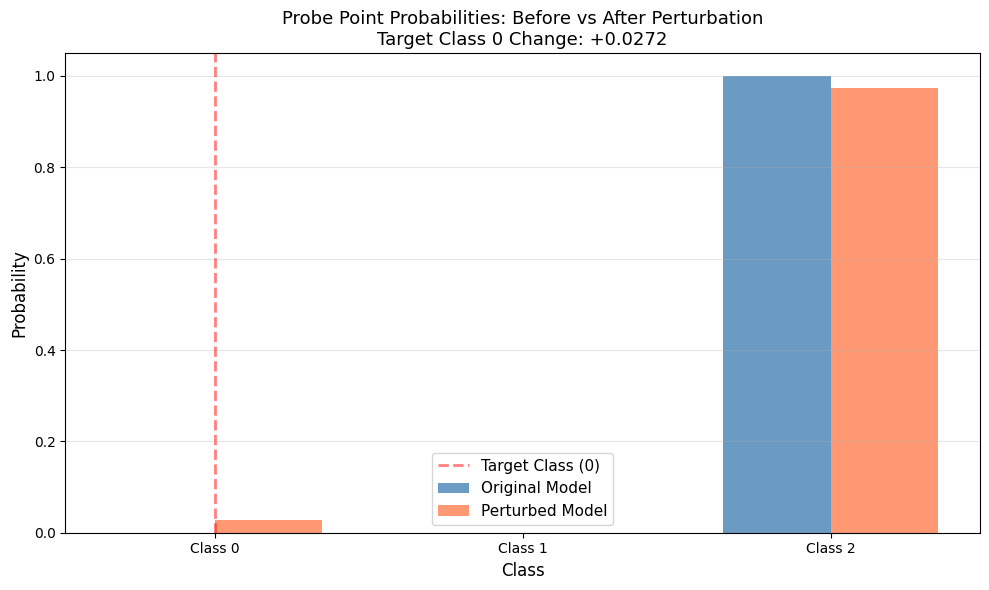

In [17]:
# Evaluate probe point before and after perturbation
with torch.no_grad():
    # Original model
    logits_orig = model(x_star.unsqueeze(0))
    probs_orig = F.softmax(logits_orig, dim=1)[0]
    
    # Retrain on perturbed data
    model_pert = MultiClassLogisticRegression(D, n_classes).to(device)
    criterion_pert = nn.CrossEntropyLoss()
    optimizer_pert = optim.SGD(model_pert.parameters(), lr=0.01)
    
# Retrain model on perturbed data (X_pert_full was created earlier)
dataset_pert = TensorDataset(X_pert_full, y_tensor)
for epoch in range(200):
    indices = torch.randperm(N)
    X_epoch = X_pert_full[indices]
    y_epoch = y_tensor[indices]
    
    for start in range(0, N, B):
        end = min(start + B, N)
        X_batch = X_epoch[start:end]
        y_batch = y_epoch[start:end]
        
        optimizer_pert.zero_grad()
        outputs = model_pert(X_batch)
        loss = criterion_pert(outputs, y_batch)
        loss.backward()
        optimizer_pert.step()

# Evaluate probe on perturbed model
with torch.no_grad():
    logits_pert = model_pert(x_star.unsqueeze(0))
    probs_pert = F.softmax(logits_pert, dim=1)[0]

# Print results
print(f"Probe point (target class: {class_star})")
print(f"\nOriginal model probabilities: {probs_orig.cpu().numpy()}")
print(f"Perturbed model probabilities: {probs_pert.cpu().numpy()}")
print(f"\nChange in target class probability: {probs_pert[class_star].item() - probs_orig[class_star].item():+.4f}")

# Visualize probability changes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
x_pos = np.arange(n_classes)
width = 0.35

bars1 = ax.bar(x_pos - width/2, probs_orig.cpu().numpy(), width, 
               label='Original Model', alpha=0.8, color='steelblue')
bars2 = ax.bar(x_pos + width/2, probs_pert.cpu().numpy(), width,
               label='Perturbed Model', alpha=0.8, color='coral')

# Highlight target class
ax.axvline(x=class_star, color='red', linestyle='--', alpha=0.5, linewidth=2,
          label=f'Target Class ({class_star})')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(f'Probe Point Probabilities: Before vs After Perturbation\n'
            f'Target Class {class_star} Change: {probs_pert[class_star].item() - probs_orig[class_star].item():+.4f}',
            fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Class {target_classes[i]}' for i in range(n_classes)])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()